In [9]:
# 1. ADIM: Maaşlardan oluşan örnek bir liste tanımlayarak başlıyoruz.
#veriyi temizleme
maaslar = [50, 45, 50, 60, 200, 55, 52, 48, 49, 53]

In [2]:
# 2. ADIM: Numpy kütüphanesini kullanarak Çeyrekler Açıklığı (IQR) yöntemi ile alt ve üst sınırları hesaplayıp aykırı değerleri (outliers) buluyoruz.
import numpy as np

maaslar = np.array([50, 45, 50, 60, 200, 55, 52, 48, 49, 53])

# Çeyrekleri hesapla
Q1 = np.percentile(maaslar, 25)
Q3 = np.percentile(maaslar, 75)
IQR = Q3 - Q1

# Alt ve üst sınır
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Alt sınır:", alt_sinir)
print("Üst sınır:", ust_sinir)

# Aykırı değerleri bul
aykiri = maaslar[(maaslar < alt_sinir) | (maaslar > ust_sinir)]

print("Aykırı değerler:", aykiri)

Q1: 49.25
Q3: 54.5
IQR: 5.25
Alt sınır: 41.375
Üst sınır: 62.375
Aykırı değerler: [200]


In [3]:
# 3. ADIM: Scipy istatistik kütüphanesi yardımıyla Z-Skoru hesaplıyor ve standart sapmanın 3 katından uzak olan değerleri aykırı olarak belirliyoruz.
from scipy import stats

z_scores = np.abs(stats.zscore(maaslar))

print("Z-Skorları:", z_scores)

# 3'ten büyük olanları aykırı kabul ediyoruz
aykiri_z = maaslar[z_scores > 3]

print("Z-score ile aykırı değerler:", aykiri_z)

Z-Skorları: [0.36184881 0.47353054 0.36184881 0.13848535 2.98860315 0.25016708
 0.31717612 0.4065215  0.38418516 0.29483977]
Z-score ile aykırı değerler: []


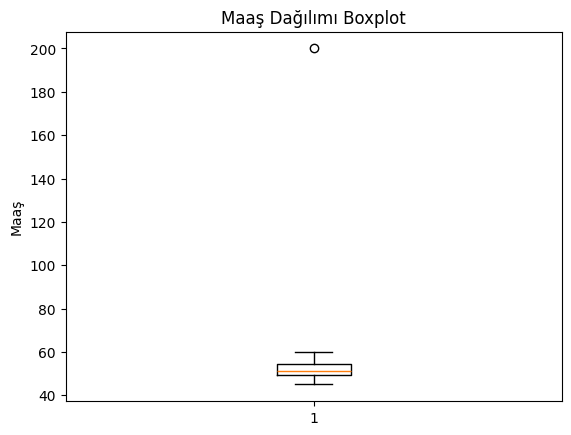

In [4]:
# 4. ADIM: Matplotlib kullanarak ilk maaş verisindeki aykırı değerleri (200 vb.) Kutu Grafiği (Boxplot) ile görsel olarak inceliyoruz.
import matplotlib.pyplot as plt

plt.boxplot(maaslar)
plt.title("Maaş Dağılımı Boxplot")
plt.ylabel("Maaş")
plt.show()

In [5]:
# 5. ADIM: İkinci bir örnek olarak, bariz bir şekilde 80 gibi bir aykırı değer içeren temizlenecek farklı bir maaş listesi tanımlıyoruz.
maaslar = [46, 47, 48, 49, 50, 51, 52, 53, 54, 80]

In [6]:
# 6. ADIM: Bu yeni sayı dizisi üzerinde yine IQR (Çeyrekler Arası Menzil) hesaplaması ile sınırları bulup 80 olan aykırı gözlemi yakalıyoruz.
import numpy as np

maaslar = np.array([46, 47, 48, 49, 50, 51, 52, 53, 54, 80])

Q1 = np.percentile(maaslar, 25)
Q3 = np.percentile(maaslar, 75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Alt sınır:", alt_sinir)
print("Üst sınır:", ust_sinir)

aykiri = maaslar[(maaslar < alt_sinir) | (maaslar > ust_sinir)]

print("IQR ile aykırı değerler:", aykiri)

Q1: 48.25
Q3: 52.75
IQR: 4.5
Alt sınır: 41.5
Üst sınır: 59.5
IQR ile aykırı değerler: [80]


In [7]:
# 3. ADIM: Scipy istatistik kütüphanesi yardımıyla Z-Skoru hesaplıyor ve standart sapmanın 3 katından uzak olan değerleri aykırı olarak belirliyoruz.
from scipy import stats

z_scores = np.abs(stats.zscore(maaslar))

print("Z-Skorları:", z_scores)

aykiri_z = maaslar[z_scores > 3]

print("Z-score ile aykırı değerler:", aykiri_z)

Z-Skorları: [0.75047877 0.64326752 0.53605627 0.42884501 0.32163376 0.21442251
 0.10721125 0.         0.10721125 2.89470384]
Z-score ile aykırı değerler: []


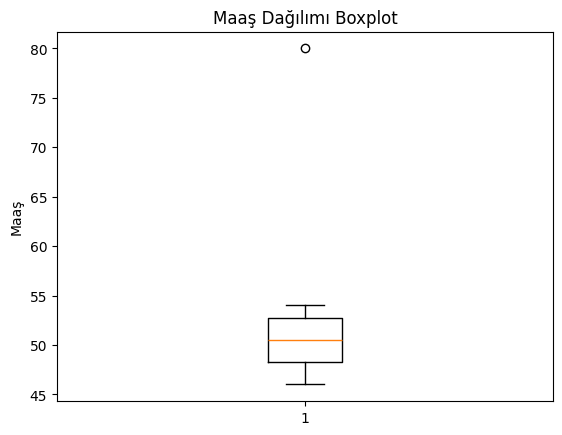

In [8]:
# 4. ADIM: Matplotlib kullanarak ilk maaş verisindeki aykırı değerleri (200 vb.) Kutu Grafiği (Boxplot) ile görsel olarak inceliyoruz.
import matplotlib.pyplot as plt

plt.boxplot(maaslar)
plt.title("Maaş Dağılımı Boxplot")
plt.ylabel("Maaş")
plt.show()

In [10]:
# 9. ADIM: Eksik veri türleri olan MCAR (Tamamen Rastgele), MAR (Rastgele) ve MNAR (Kendi Değerine Bağlı) kavramlarını açıklıyoruz.
#Eksik Veri Türleri Notları
#1️⃣ MCAR (Missing Completely At Random) – Tamamen Rastgele Eksik Veri

#Tanım:
#Eksik veri, tamamen rastgele ortaya çıkar ve ne diğer değişkenlere ne de kendi değerine bağlıdır.

#Örnek:

#Öğrencilerin sınav kağıtlarından bazıları rüzgârla uçtu.

#Bir anketin bazı sayfaları kayboldu.

#Özellikler:

#Eksiklik şansa bağlıdır.

#Eksik verileri çıkarmak analizde yanlılık yaratmaz.

#2️⃣ MAR (Missing At Random) – Rastgele Eksik Veri (Başka Değişkene Bağlı)

#Tanım:
#Eksik veri, kendisiyle ilişkili değildir ama başka bir değişkene bağlıdır.

#Örnek:

#Gelir sorusu anketinde bazı yüksek gelirli kişiler atlamış olabilir.

#Cinsiyete göre bazı sorular daha çok boş bırakılmış olabilir.

#Özellikler:

#Eksiklik sistematik ama başka bir değişkenle açıklanabilir.

#Analiz yaparken bu ilişkiyi göz önünde bulundurmak gerekir (ör. imputasyon yöntemleri).

#3️⃣ MNAR (Missing Not At Random) – Kendi Değerine Bağlı Eksik Veri

#Tanım:
#Eksik veri, doğrudan kendi değerine bağlı olarak ortaya çıkar.

#Örnek:

#Düşük gelirli kişiler gelirlerini anketlerde yazmıyor.

#Hasta olan kişiler sağlık durumunu paylaşmıyor.

#Özellikler:

#Eksiklik sistematik ve kendi değeriyle ilişkili.

#Analiz çok dikkat gerektirir; imputasyon zor veya yanlı olabilir.
import numpy as np # linear algebra
import pandas as pd # d

In [14]:
# 10. ADIM: İçinde hiçbir eksik (boş) veri olmayan, temiz bir örnek Eğitim/Öğrenci tablosu oluşturuyoruz.
import pandas as pd
import numpy as np

# Öğrenci isimleri ve notları
data = {
    "Student": [f"Student{i}" for i in range(1, 11)],
    "Math": [85, 92, 78, 90, 66, 88, 95, 70, 82, 75],
    "English": [78, 85, 80, 88, 60, 90, 95, 72, 84, 70],
    "Attendance": [90, 95, 85, 100, 60, 80, 98, 70, 88, 75]
}

df = pd.DataFrame(data)

In [15]:
# 11. ADIM: Tamamen Rastgele Eksik Veri (MCAR) simüle etmek için tablodaki Math (Matematik) sütunundaki bazı notları rastgele 'NaN' (boş) olarak siliyoruz.
# MCAR: rastgele eksik Math notu
np.random.seed(42)
df.loc[df.sample(frac=0.2).index, "Math"] = np.nan

In [16]:
# TABLO KONTROLÜ: DataFrame içeriğini konsola yazdırıp inceliyoruz.
print(df)

     Student  Math  English  Attendance
0   Student1  85.0       78          90
1   Student2   NaN       85          95
2   Student3  78.0       80          85
3   Student4  90.0       88         100
4   Student5  66.0       60          60
5   Student6  88.0       90          80
6   Student7  95.0       95          98
7   Student8  70.0       72          70
8   Student9   NaN       84          88
9  Student10  75.0       70          75


In [17]:
# 13. ADIM: Başka bir değişkene bağlı eksik veri (MAR) oluşturmak için, Yoklaması (Attendance) 80'den düşük olanların İngilizce notlarını siliyoruz.
# MAR: düşük Attendance ile English notu eksik (Attendance<80 ise)
df.loc[df["Attendance"] < 80, "English"] = np.nan

In [18]:
# TABLO KONTROLÜ: DataFrame içeriğini konsola yazdırıp inceliyoruz.
print(df)

     Student  Math  English  Attendance
0   Student1  85.0     78.0          90
1   Student2   NaN     85.0          95
2   Student3  78.0     80.0          85
3   Student4  90.0     88.0         100
4   Student5  66.0      NaN          60
5   Student6  88.0     90.0          80
6   Student7  95.0     95.0          98
7   Student8  70.0      NaN          70
8   Student9   NaN     84.0          88
9  Student10  75.0      NaN          75


In [19]:
# 14. ADIM: Kendi değerine bağlı eksik veri (MNAR) oluşturmak için, 70'den düşük Matematik notlarını veri setinden gizleyip siliyoruz.
# MNAR: kendi değeri düşükse Math eksik (Math<70)
df.loc[df["Math"] < 70, "Math"] = np.nan

In [20]:
# TABLO KONTROLÜ: DataFrame içeriğini konsola yazdırıp inceliyoruz.
print(df)

     Student  Math  English  Attendance
0   Student1  85.0     78.0          90
1   Student2   NaN     85.0          95
2   Student3  78.0     80.0          85
3   Student4  90.0     88.0         100
4   Student5   NaN      NaN          60
5   Student6  88.0     90.0          80
6   Student7  95.0     95.0          98
7   Student8  70.0      NaN          70
8   Student9   NaN     84.0          88
9  Student10  75.0      NaN          75


In [21]:
# 15. ADIM: Çeşit çeşit boş (eksik) veri ürettiğimiz bu zorlu tabloyu artık bilgisayarımıza 'CSV' formatında kaydediyoruz.
df.to_csv("student_scores.csv", index=False)


In [22]:
# TABLO KONTROLÜ: DataFrame içeriğini konsola yazdırıp inceliyoruz.
print(df)

     Student  Math  English  Attendance
0   Student1  85.0     78.0          90
1   Student2   NaN     85.0          95
2   Student3  78.0     80.0          85
3   Student4  90.0     88.0         100
4   Student5   NaN      NaN          60
5   Student6  88.0     90.0          80
6   Student7  95.0     95.0          98
7   Student8  70.0      NaN          70
8   Student9   NaN     84.0          88
9  Student10  75.0      NaN          75


In [23]:
# 16. ADIM: Eksik verilerle başa çıkma ve temizleme yöntemlerine geçiş yapıyoruz.
#Eksik veriyi temizleme yöntemleri

In [25]:
# 17. ADIM: Eksik veri temizlemenin en ilkel ve acımasız yolu olan SİLME (Deletion) yöntemiyle, içinde eksik olan tüm satırları ve sütunları siliyoruz.
#1️⃣ Silme Yöntemi (Deletion Method)
import pandas as pd
df = pd.read_csv("student_scores.csv")

# Satır silme: eksik veri içeren tüm satırları kaldır
df_drop_rows = df.dropna()

# Sütun silme: eksik veri içeren tüm sütunları kaldır
df_drop_cols = df.dropna(axis=1)

print("Satır silme sonrası:")
print(df_drop_rows)
print("\nSütun silme sonrası:")
print(df_drop_cols)

Satır silme sonrası:
    Student  Math  English  Attendance
0  Student1  85.0     78.0          90
2  Student3  78.0     80.0          85
3  Student4  90.0     88.0         100
5  Student6  88.0     90.0          80
6  Student7  95.0     95.0          98

Sütun silme sonrası:
     Student  Attendance
0   Student1          90
1   Student2          95
2   Student3          85
3   Student4         100
4   Student5          60
5   Student6          80
6   Student7          98
7   Student8          70
8   Student9          88
9  Student10          75


In [27]:
# 18. ADIM: Eksik verileri doldurma (Imputation): Boş Matematik notlarını ortalamayla (mean), İngilizce notlarını ise medyan ile güvenceye alacak şekilde dolduruyoruz.
#2️⃣ Ortalama / Medyan / Mod ile Doldurma (Imputation)
# Math notlarını ortalama ile doldurma
df['Math_filled_mean'] = df['Math'].fillna(df['Math'].mean())

# English notlarını medyan ile doldurma
df['English_filled_median'] = df['English'].fillna(df['English'].median())

print(df)

     Student  Math  English  Attendance  Math_filled_mean  \
0   Student1  85.0     78.0          90              85.0   
1   Student2   NaN     85.0          95              83.0   
2   Student3  78.0     80.0          85              78.0   
3   Student4  90.0     88.0         100              90.0   
4   Student5   NaN      NaN          60              83.0   
5   Student6  88.0     90.0          80              88.0   
6   Student7  95.0     95.0          98              95.0   
7   Student8  70.0      NaN          70              70.0   
8   Student9   NaN     84.0          88              83.0   
9  Student10  75.0      NaN          75              75.0   

   English_filled_median  
0                   78.0  
1                   85.0  
2                   80.0  
3                   88.0  
4                   85.0  
5                   90.0  
6                   95.0  
7                   85.0  
8                   84.0  
9                   85.0  


In [29]:
# 19. ADIM: Tahmin Yöntemi (KNNImputer): Makine öğrenmesinin en yakın komşu mantığını kullanarak boş not puanlarını yapay zekaya tahminle doldurtuyoruz.
#3️⃣ Tahmin Yöntemi (Predictive Imputation)
from sklearn.impute import KNNImputer
import numpy as np

imputer = KNNImputer(n_neighbors=2)
df_knn = df.copy()
df_knn[['Math','English']] = imputer.fit_transform(df_knn[['Math','English']])

print(df_knn)

     Student  Math    English  Attendance  Math_filled_mean  \
0   Student1  85.0  78.000000          90              85.0   
1   Student2  84.0  85.000000          95              83.0   
2   Student3  78.0  80.000000          85              78.0   
3   Student4  90.0  88.000000         100              90.0   
4   Student5  83.0  85.714286          60              83.0   
5   Student6  88.0  90.000000          80              88.0   
6   Student7  95.0  95.000000          98              95.0   
7   Student8  70.0  79.000000          70              70.0   
8   Student9  84.0  84.000000          88              83.0   
9  Student10  75.0  79.000000          75              75.0   

   English_filled_median  
0                   78.0  
1                   85.0  
2                   80.0  
3                   88.0  
4                   85.0  
5                   90.0  
6                   95.0  
7                   85.0  
8                   84.0  
9                   85.0  


In [ ]:
# 20. ADIM: Veri içindeki hatalı değerleri temsil eden Gürültülü Veri konusu için ufak bir bilgi notu düşüyoruz.
#Gürültüllü veri
#Gürültülü Veri (Noisy Data)
#Tanım

#Gürültülü veri, hatalı, yanlış veya beklenmedik değerler içeren veridir.

#Genellikle veri toplama, ölçüm hataları veya veri giriş hatalarından kaynaklanır.

#Örnekler:

#Sınav notu 105 gibi bir değer (0–100 aralığında olamaz).

#Kişi yaşını “-5” olarak girmiş.

#Kategorik veride “Fmale” yerine “Femail” yazılmış.

In [30]:
# 21. ADIM: Kaggle platformunun meşhur Titanic yarışmasından gender_submission.csv dosyasını okutarak gerçek veri deneyimine geçiş yapıyoruz.
import pandas as pd
df = pd.read_csv('gender_submission.csv')
# Burada temizlik işlemlerini yapabilirsin

In [31]:
# 22. ADIM: Titanic veri setinin yapısını daha iyi anlamak için tablodaki ilk 5 satırı yazdırıp önizleme yapıyoruz.
# 1. Veriye ilk bakış (İlk 5 satırı gösterir)
print("Verinin İlk 5 Satırı:")
print(df.head())

Verinin İlk 5 Satırı:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


In [33]:
# 23. ADIM: Titanic verisindeki hangi sütunda toplam kaç tane eksik değer (NaN) olduğunu saydırıyoruz.
# 2. Eksik Veri Kontrolü (Hangi sütunda kaç tane boş değer var?)
print("\nEksik Veri Sayısı:")
print(df.isnull().sum())


Eksik Veri Sayısı:
PassengerId    0
Survived       0
dtype: int64


In [34]:
# 24. ADIM: Tablodaki alanların veri tiplerini (sayı mı, yazı mı?) ve bellek üzerindeki durumunu check ediyoruz.
# 3. Veri Tiplerini Kontrol Etme (Sayılar sayı mı, metinler metin mi?)
print("\nVeri Tipleri Bilgisi:")
print(df.info())


Veri Tipleri Bilgisi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   PassengerId  418 non-null    int64
 1   Survived     418 non-null    int64
dtypes: int64(2)
memory usage: 6.7 KB
None


In [35]:
# 25. ADIM: Sayısal verilerin tamamına (min, max, sapma vs.) bakılarak anormallikleri (gürültü ve aykırı değerleri) özetliyoruz.
# 4. İstatistiksel Özet (Aykırı değerleri anlamak için: min, max, ortalama)
print("\nİstatistiksel Özet:")
print(df.describe())


İstatistiksel Özet:
       PassengerId    Survived
count   418.000000  418.000000
mean   1100.500000    0.363636
std     120.810458    0.481622
min     892.000000    0.000000
25%     996.250000    0.000000
50%    1100.500000    0.000000
75%    1204.750000    1.000000
max    1309.000000    1.000000


In [36]:
# 26. ADIM: Eksik verilerin sayılarına emin olmak için tekrar doğrulama yapıyoruz.
# Eksik değer var mı tekrar kontrol edelim
print("Eksik değer sayısı:\n", df.isnull().sum())

Eksik değer sayısı:
 PassengerId    0
Survived       0
dtype: int64


In [37]:
# 27. ADIM: Yolcu ID'si ve hayatta kalma durumları gibi önemli sütunlarda eksik veri varsa bunları ortanca değer (medyan) ile hemen dolduruyoruz.
# Eğer eksik veri varsa örneğin medyan veya 0 ile doldurabiliriz
# Burada 'Survived' ve 'PassengerId' sütunları olduğu için genelde eksik yoktur, ama kontrol etmeliyiz
df['Survived'].fillna(df['Survived'].median(), inplace=True)
df['PassengerId'].fillna(df['PassengerId'].median(), inplace=True)

/tmp/ipykernel_607/1173028492.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Survived'].fillna(df['Survived'].median(), inplace=True)
/tmp/ipykernel_607/1173028492.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [38]:
# 28. ADIM: 'Survived' (Hayatta Kalanlar) sütununu basit bir numara olmaktan çıkarıp analiz için onu bir kategori haline (Kategorik Dönüşüm) getiriyoruz.
df['Survived'] = df['Survived'].astype('category')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  418 non-null    int64   
 1   Survived     418 non-null    category
dtypes: category(1), int64(1)
memory usage: 3.9 KB
None


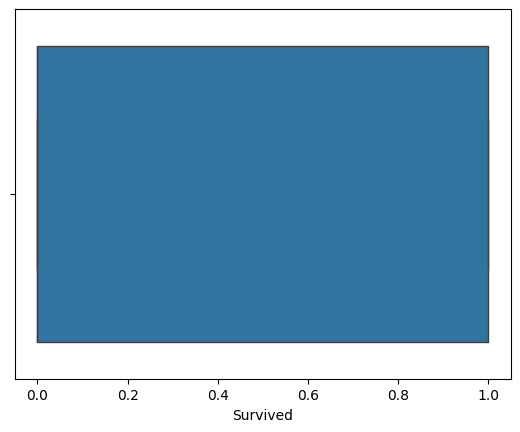

In [39]:
# 29. ADIM: Seaborn kütüphanesini dahil edip Kategorik olan Survived (Kurtulanlar) değerlerini kutu grafiğiyle görselleştiriyoruz.
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot ile Survived değerlerini görselleştirelim
sns.boxplot(x='Survived', data=df)
plt.show()

In [40]:
# 30. ADIM: Eksik değerler giderildikten sonra temizlenmiş veri setimizin ilk 5 satırını ve genel eksikleri tekrar yazdırıyoruz.
# Temizlenmiş veri seti hakkında kısa özet
print("Temizlenmiş veri seti ilk 5 satır:\n", df.head())
print("\nVeri tipleri:\n", df.dtypes)
print("\nEksik değerler:\n", df.isnull().sum())

Temizlenmiş veri seti ilk 5 satır:
    PassengerId Survived
0          892        0
1          893        1
2          894        0
3          895        0
4          896        1

Veri tipleri:
 PassengerId       int64
Survived       category
dtype: object

Eksik değerler:
 PassengerId    0
Survived       0
dtype: int64


In [41]:
# 31. ADIM: Artık Titanic gemisinin en kapsamlı ana tablosu olan 'train.csv' (Eğitim) verisini analizi ileriye taşımak için Jupyter'e dahil ediyoruz.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi oku (train.csv dosyasının yüklü olduğundan emin ol)
df = pd.read_csv('train.csv')

In [42]:
# 32. ADIM: İleri düzey özet: Makine öğrenmesine zarar verebilecek uç aykırı değerler bulmak amacıyla Age (Yaş) ve Fare (Bilet Ücreti) için özet çekiyoruz.
#Verideki mantıksız değerleri (örneğin 0 TL bilet ücreti veya çok uç yaşlar) görmek için describe() komutunu kullanırız.
# Sayısal sütunların özetini çıkar
#Burada neye bakmalısın?
#Min değerine bak: Bilet ücreti 0 mı? (Bu bir gürültü/hata olabilir).
#Max değerine bak: Yaş 200 mü girilmiş? (Bu imkansız bir değerdir).
print(df[['Age', 'Fare']].describe())

              Age        Fare
count  714.000000  891.000000
mean    29.699118   32.204208
std     14.526497   49.693429
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     80.000000  512.329200


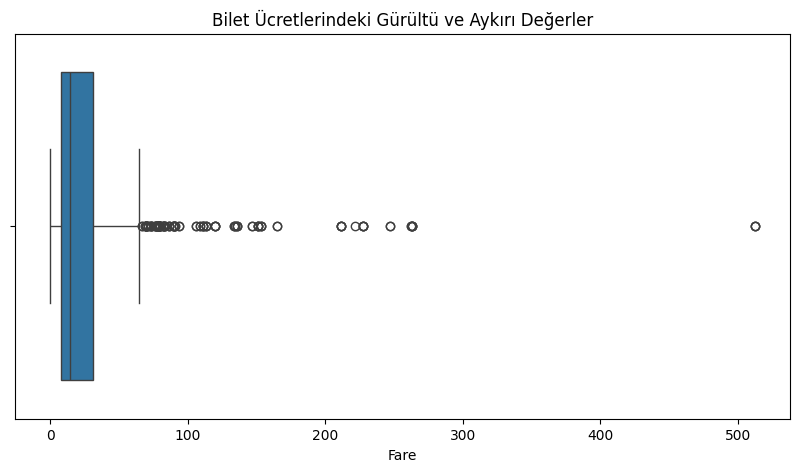

In [43]:
# 33. ADIM: Titanic bilet tablosunda çokça yer alan şüpheli ve gürültülü (aykırı) ödemeleri net bir şekilde görmek için Bilet Parası'nı çizdiriyoruz.
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Fare'])
plt.title("Bilet Ücretlerindeki Gürültü ve Aykırı Değerler")
plt.show()

In [44]:
# 34. ADIM: Yaşlardaki (Age) ufak farkları (Gürültü) ortadan kaldırmak için, pd.cut() ile yolcuları 5 farklı yaş aralığı kategorisine (Binning işlemi) bölüyoruz.
# Yaş sütunundaki gürültüyü azaltmak için gruplandırma yapalım
bins = [0, 12, 20, 40, 60, 80]
labels = ['Çocuk', 'Ergen', 'Genç Yetişkin', 'Yetişkin', 'Yaşlı']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(df[['Age', 'Age_Group']].head(10))

    Age      Age_Group
0  22.0  Genç Yetişkin
1  38.0  Genç Yetişkin
2  26.0  Genç Yetişkin
3  35.0  Genç Yetişkin
4  35.0  Genç Yetişkin
5   NaN            NaN
6  54.0       Yetişkin
7   2.0          Çocuk
8  27.0  Genç Yetişkin
9  14.0          Ergen


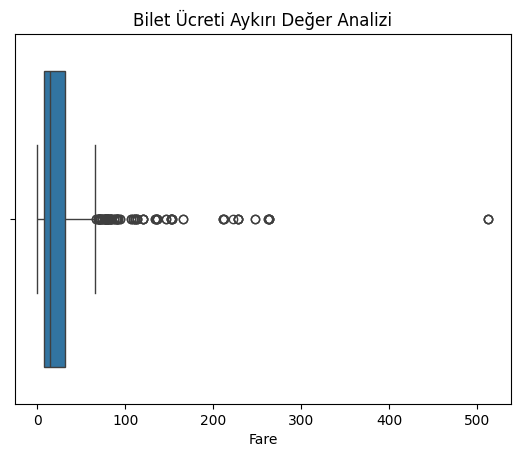

In [45]:
# 35. ADIM: Boxplot incelemesini daha iyi anlamak için bilet ücretlerindeki aykırı durumları (noktalar) sade başlıkla görselleştiriyoruz.
import seaborn as sns
import matplotlib.pyplot as plt

# Kutu grafiği ile aykırı değerleri (noktaları) görelim
sns.boxplot(x=df['Fare'])
plt.title("Bilet Ücreti Aykırı Değer Analizi")
plt.show()

In [47]:
# 36. ADIM: IQR Yöntemi (1.5 Kuralı) formülünü çalıştırarak Fare (Bilet Ücretinin) üst sınırını geçip aykırı olan tam 116 kişiyi yakalıyoruz.
# 1. Fare (Bilet Ücreti) sütunu için Çeyreklik değerleri hesaplayalım
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

# 2. Alt ve üst sınırları belirleyelim (Standart kural: 1.5 * IQR)
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

# 3. Aykırı değerleri "yakalayalım"
aykiri_gozlemler = df[(df['Fare'] < alt_sinir) | (df['Fare'] > ust_sinir)]

print(f"Bilet Ücreti için Üst Sınır: {ust_sinir:.2f}")
print(f"Yakalanan Aykırı Gözlem Sayısı: {len(aykiri_gozlemler)}")
print("-" * 30)
print("İşte yakalanan ilk 5 aykırı değer:")
print(aykiri_gozlemler[['Name', 'Fare', 'Pclass']].head())

Bilet Ücreti için Üst Sınır: 65.63
Yakalanan Aykırı Gözlem Sayısı: 116
------------------------------
İşte yakalanan ilk 5 aykırı değer:
                                                 Name      Fare  Pclass
1   Cumings, Mrs. John Bradley (Florence Briggs Th...   71.2833       1
27                     Fortune, Mr. Charles Alexander  263.0000       1
31     Spencer, Mrs. William Augustus (Marie Eugenie)  146.5208       1
34                            Meyer, Mr. Edgar Joseph   82.1708       1
52           Harper, Mrs. Henry Sleeper (Myna Haxtun)   76.7292       1


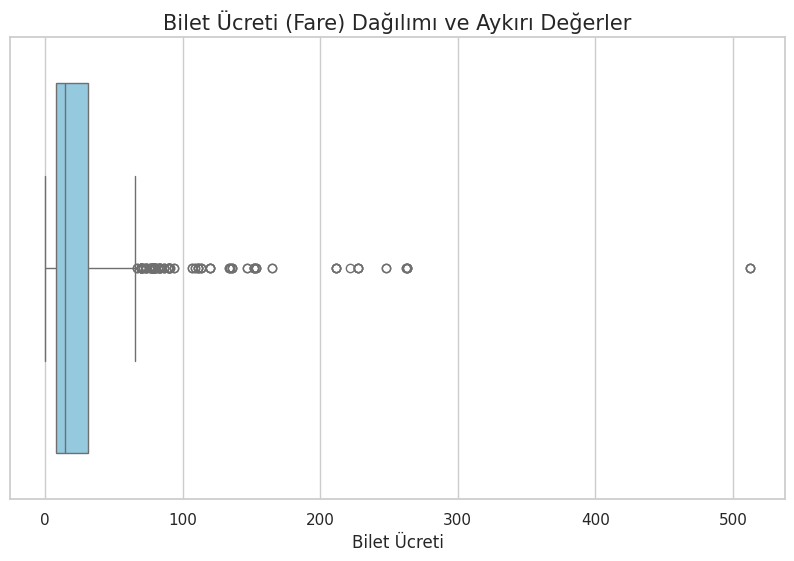

In [48]:
# 37. ADIM: IQR formülü ile yakaladığımız Fare anormalliklerini daha şık bir arkaplan tasarımı (whitegrid) yaratarak tekrar çizdiriyoruz.
import seaborn as sns
import matplotlib.pyplot as plt

# Grafik stilini belirleyelim
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
# 'Fare' (Bilet Ücreti) sütunu için kutu grafiği çizelim
sns.boxplot(x=df['Fare'], color='skyblue')

plt.title('Bilet Ücreti (Fare) Dağılımı ve Aykırı Değerler', fontsize=15)
plt.xlabel('Bilet Ücreti', fontsize=12)
plt.show()

In [49]:
# 38. ADIM: Bilet parası (Fare) hiç ödemeyenleri (0 TL olanları) uç ve gürültülü değerler kapsamında tespit ederek sayılarına ulaşıyoruz (15 kişi).
# Bileti 0 TL olan kişileri filtrele ve sayısını bul
sifir_biletliler = df[df['Fare'] == 0]
kisi_sayisi = len(sifir_biletliler)

print(f"Bileti 0 TL olan toplam kişi sayısı: {kisi_sayisi}")
print("-" * 30)
print("Bu kişilerden bazıları:")
print(sifir_biletliler[['Name', 'Pclass', 'Sex', 'Survived']].head(10))

Bileti 0 TL olan toplam kişi sayısı: 15
------------------------------
Bu kişilerden bazıları:
                                 Name  Pclass   Sex  Survived
179               Leonard, Mr. Lionel       3  male         0
263             Harrison, Mr. William       1  male         0
271      Tornquist, Mr. William Henry       3  male         1
277       Parkes, Mr. Francis "Frank"       2  male         0
302   Johnson, Mr. William Cahoone Jr       3  male         0
413    Cunningham, Mr. Alfred Fleming       2  male         0
466             Campbell, Mr. William       2  male         0
481  Frost, Mr. Anthony Wood "Archie"       2  male         0
597               Johnson, Mr. Alfred       3  male         0
633     Parr, Mr. William Henry Marsh       1  male         0


In [50]:
# 39. ADIM: Temizliğin omurgası olan Eksik Değer Kontrolü ile hem boş verileri saydırıyor hem de tablonun yüzde (%) kaçının eksik olduğunu buluyoruz.
print("Eksik Değer Sayıları:")
print(df.isnull().sum())

# Yüzdesel olarak görelim (Hangi sütun ne kadar sorunlu?)
eksik_oranı = (df.isnull().sum() / len(df)) * 100
print("\nEksik Veri Yüzdesi (%):")
print(eksik_oranı)

Eksik Değer Sayıları:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Age_Group      177
dtype: int64

Eksik Veri Yüzdesi (%):
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
Age_Group      19.865320
dtype: float64


In [59]:
# 40. ADIM: İlk Doldurma (Imputation): Yaşı medyanla, biniş limanını (Embarked) modla doldurup hatalı Kabin numarasını 'Unknown' etiketine çekiyoruz.
#Bu işlemi yapmasaydık, bir yapay zeka modeli kurmaya çalıştığında bilgisayar
#"Ben bu boş hücreyle ne yapacağımı bilmiyorum" diyerek hata verecekti. Şimdi verimiz çok daha "sağlam" hale geldi.
# 1. Yaş sütununu Medyan (orta değer) ile dolduralım
# (Ortalama yerine medyan seçtik çünkü aykırı değerlerden etkilenmez)
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Embarked sütunundaki 2 eksik veriyi en çok tekrar eden (Mod) limanla dolduralım
en_cok_tekrar_eden_liman = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(en_cok_tekrar_eden_liman)

# 3. Cabin sütunu çok boş olduğu için onu "Unknown" (Bilinmiyor) yapalım
df['Cabin'] = df['Cabin'].fillna('Unknown')

print("Doldurma işlemi sonrası kontrol:")
print(df.isnull().sum())

Doldurma işlemi sonrası kontrol:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin            0
Embarked         0
Age_Group      177
dtype: int64


In [60]:
# 41. ADIM: Yaş sütunundaki (Age) medyan doldurmasından emin olduktan sonra yaşları sağlıklı olan yeni sınır ve etiketlerle işlevsel gruplara dönüştürüyoruz.
# 1. Önce yaşları doldurduğumuzdan emin olalım (Garantiye alıyoruz)
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Aralığı biraz genişletelim (0'dan 100'e kadar) ki kimse dışarıda kalmasın
bins = [0, 12, 18, 35, 60, 100]
labels = ['Çocuk', 'Genç', 'Genç Yetişkin', 'Yetişkin', 'Yaşlı']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 3. Nerede hata olduğunu anlamak için kontrol edelim
print("Age_Group içindeki değerlerin dağılımı:")
print(df['Age_Group'].value_counts(dropna=False))

# 4. Hala boş kalan var mı bakalım?
print("\nBoş kalan satır sayısı:", df['Age_Group'].isnull().sum())

Age_Group içindeki değerlerin dağılımı:
Age_Group
Genç Yetişkin    535
Yetişkin         195
Genç              70
Çocuk             69
Yaşlı             22
Name: count, dtype: int64

Boş kalan satır sayısı: 0


In [61]:
# 42. ADIM: Makine öğrenmesini hazırlamak için (Encoding), Cinsiyet alanında modele gönderilecek ne çeşit benzersiz metinler olduğuna bakıyoruz.
# 1. Cinsiyet sütununda farklı yazımlar var mı?
print("Cinsiyet Değerleri:")
print(df['Sex'].unique())

Cinsiyet Değerleri:
['male' 'female']


In [62]:
# 43. ADIM: Biniş limanı alanında (Embarked) S, C, Q harflerinden başka ne tarz kısaltma değerleri (veya anomali) olduğuna bakıyoruz.
# 2. Biniş Limanı sütununda farklı yazımlar var mı?
print("\nLiman Değerleri:")
print(df['Embarked'].unique())


Liman Değerleri:
['S' 'C' 'Q']


In [63]:
# 44. ADIM: Kodladığımız Yaş Grup Kategorilerinde (Age_Group) toplamda hangi sınıflandırmaların aktif durduğuna hızlıca bakıyoruz.
print("\nYaş Grubu Kategorileri:")
print(df['Age_Group'].unique())


Yaş Grubu Kategorileri:
['Genç Yetişkin', 'Yetişkin', 'Çocuk', 'Genç', 'Yaşlı']
Categories (5, object): ['Çocuk' < 'Genç' < 'Genç Yetişkin' < 'Yetişkin' < 'Yaşlı']


In [64]:
# 45. ADIM: KATEGORİK DÖNÜŞÜM: Cinsiyet verilerini Female=0, Male=1 olacak şekilde sayısallaştırıp yapay zekanın (modelin) bu veriyi anlamasını sağlıyoruz.
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

In [65]:
# 46. ADIM: KATEGORİK DÖNÜŞÜM: Limanları da aynı şekilde S=0, C=1, Q=2 kodlarına atayarak metin (string) veri bırakmıyoruz.
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [67]:
# 47. ADIM: KATEGORİK DÖNÜŞÜM: Yaş kategorilerini hiyerarşik bir düzene (Ordinal Encoding) sığdırarak sayısallaştırıyoruz.
# Yaş gruplarını hiyerarşik olarak sayısallaştıralım
age_mapping = {'Çocuk': 0, 'Genç': 1, 'Genç Yetişkin': 2, 'Yetişkin': 3, 'Yaşlı': 4}
df['Age_Group_Encoded'] = df['Age_Group'].map(age_mapping)
# Sonucu kontrol et
print(df[['Age_Group', 'Age_Group_Encoded']].head())

       Age_Group Age_Group_Encoded
0  Genç Yetişkin                 2
1       Yetişkin                 3
2  Genç Yetişkin                 2
3  Genç Yetişkin                 2
4  Genç Yetişkin                 2


In [68]:
# 48. ADIM: ÖNEMSİZ VERİLERİN ATILMASI: İsim, Bilet no ve gereksiz tüm verileri Drop fonksiyonu ile siliyoruz.
df_final = df.drop(['Name', 'Ticket', 'PassengerId', 'Cabin', 'Age_Group'], axis=1)

In [69]:
# 49. ADIM: VERİ TEMİZLİĞİ KUSURSUZ ŞEKİLDE ZİRVEYE ULAŞTI! Sonuçların ilk 5 satırını yazıp çalışmayı gururla tamamlıyoruz.
print("\nTEBRİKLER! Veri Seti Tamamen Temizlendi ve Dönüştürüldü.")
print(df_final.head())


TEBRİKLER! Veri Seti Tamamen Temizlendi ve Dönüştürüldü.
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  \
0         0       3    1  22.0      1      0   7.2500         0   
1         1       1    0  38.0      1      0  71.2833         1   
2         1       3    0  26.0      0      0   7.9250         0   
3         1       1    0  35.0      1      0  53.1000         0   
4         0       3    1  35.0      0      0   8.0500         0   

  Age_Group_Encoded  
0                 2  
1                 3  
2                 2  
3                 2  
4                 2  
